In [2]:
# Starts here
import numpy as np, pandas as pd, random, math, sys
import matplotlib.pyplot as plt
from sklearn.preprocessing import StandardScaler
from tslearn.clustering import TimeSeriesKMeans
from torch import nn, optim
from learning_shapelets import LearningShapelets
from sklearn.model_selection import train_test_split


In [3]:
# sensorData = pd.read_csv('features_train_test_copy.csv')
sensorData = pd.read_csv('features_train_test.csv')

sensorData = sensorData.iloc[:,1:]


print(sensorData)

          Time  Force  X_axis  Y_axis  Z_axis  Class
0         0.02      0   -78.0   420.0 -2508.0      1
1         0.04      0   -73.5   418.5 -2508.0      1
2         0.06      0   -72.0   421.5 -2508.0      1
3         0.08      0   -75.0   417.0 -2508.0      1
4          0.1      1   -69.0   418.5 -2509.5      1
...        ...    ...     ...     ...     ...    ...
15995  79.9186    757  6012.0  8578.5 -3121.5      4
15996  79.9386    759  5953.5  8373.0 -2952.0      4
15997  79.9586    757  5878.5  8208.0 -2808.0      4
15998  79.9786    759  5773.5  8052.0 -2650.5      4
15999  79.9986    760  5758.5  8026.5 -2622.0      4

[16000 rows x 6 columns]


In [4]:
numClasses = 4

classOne = sensorData.iloc[:int(1*(len(sensorData)/numClasses)), :]
print(classOne)
classTwo = sensorData.iloc[int(1*(len(sensorData)/numClasses)):int(2*(len(sensorData)/numClasses)), :]
print(classTwo)
classThree = sensorData.iloc[int(2*(len(sensorData)/numClasses)):int(3*(len(sensorData)/numClasses)), :]
print(classThree)
classFour = sensorData.iloc[int(3*(len(sensorData)/numClasses)):int(4*(len(sensorData)/numClasses)), :]
print(classFour)

Time = np.arange(int(1*(len(sensorData)/numClasses)))

         Time  Force  X_axis  Y_axis  Z_axis  Class
0        0.02      0   -78.0   420.0 -2508.0      1
1        0.04      0   -73.5   418.5 -2508.0      1
2        0.06      0   -72.0   421.5 -2508.0      1
3        0.08      0   -75.0   417.0 -2508.0      1
4         0.1      1   -69.0   418.5 -2509.5      1
...       ...    ...     ...     ...     ...    ...
3995  79.9186      0   -82.5   415.5 -2524.5      1
3996  79.9386      0   -79.5   420.0 -2524.5      1
3997  79.9586      0   -85.5   415.5 -2524.5      1
3998  79.9786      2   -85.5   417.0 -2524.5      1
3999  79.9986      0   -82.5   421.5 -2526.0      1

[4000 rows x 6 columns]
         Time  Force  X_axis  Y_axis  Z_axis  Class
4000               0  -112.5   574.5 -2802.0      2
4001     0.04     -1  -123.0   591.0 -2829.0      2
4002     0.06      0  -115.5   594.0 -2824.5      2
4003     0.08      0  -117.0   591.0 -2824.5      2
4004      0.1     -1  -112.5   591.0 -2821.5      2
...       ...    ...     ...     ...   

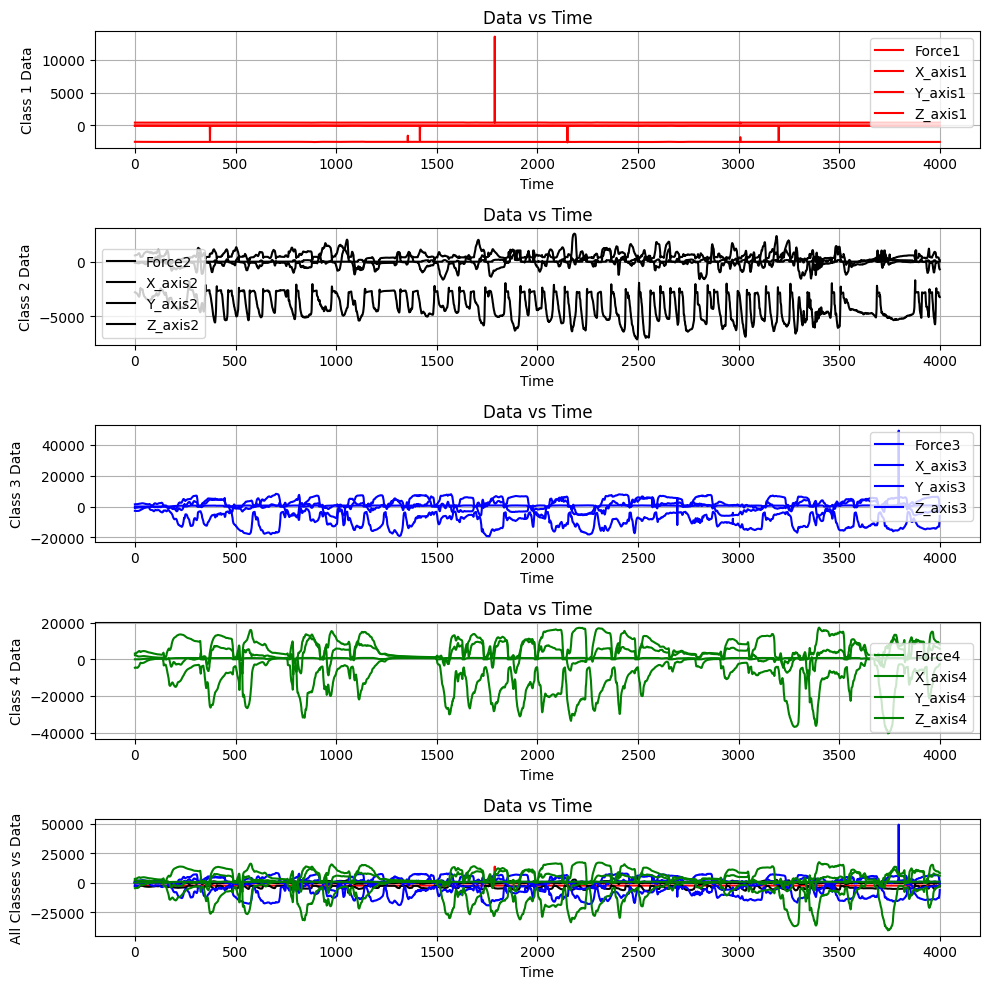

In [5]:
plt.figure("ArduinoDataAnalysis", figsize=(10, 10))

plt.subplot(5, 1, 1)
plt.plot(Time, classOne['Force'], label='Force1', color='r')
plt.plot(Time, classOne['X_axis'], label='X_axis1', color='r')
plt.plot(Time, classOne['Y_axis'], label='Y_axis1', color='r')
plt.plot(Time, classOne['Z_axis'], label='Z_axis1', color='r')
plt.xlabel('Time')
plt.ylabel('Class 1 Data')
plt.title('Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 2)
plt.plot(Time, classTwo['Force'], label='Force2', color='k')
plt.plot(Time, classTwo['X_axis'], label='X_axis2', color='k')
plt.plot(Time, classTwo['Y_axis'], label='Y_axis2', color='k')
plt.plot(Time, classTwo['Z_axis'], label='Z_axis2', color='k')
plt.xlabel('Time')
plt.ylabel('Class 2 Data')
plt.title('Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 3)
plt.plot(Time, classThree['Force'], label='Force3', color='b')
plt.plot(Time, classThree['X_axis'], label='X_axis3', color='b')
plt.plot(Time, classThree['Y_axis'], label='Y_axis3', color='b')
plt.plot(Time, classThree['Z_axis'], label='Z_axis3', color='b')
plt.xlabel('Time')
plt.ylabel('Class 3 Data')
plt.title('Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 4)
plt.plot(Time, classFour['Force'], label='Force4', color='g')
plt.plot(Time, classFour['X_axis'], label='X_axis4', color='g')
plt.plot(Time, classFour['Y_axis'], label='Y_axis4', color='g')
plt.plot(Time, classFour['Z_axis'], label='Z_axis4', color='g')
plt.xlabel('Time')
plt.ylabel('Class 4 Data')
plt.title('Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 5)
plt.plot(Time, classOne['Force'], label='Force1', color='r')
plt.plot(Time, classOne['X_axis'], label='X_axis1', color='r')
plt.plot(Time, classOne['Y_axis'], label='Y_axis1', color='r')
plt.plot(Time, classOne['Z_axis'], label='Z_axis1', color='r')

plt.plot(Time, classTwo['Force'], label='Force2', color='k')
plt.plot(Time, classTwo['X_axis'], label='X_axis2', color='k')
plt.plot(Time, classTwo['Y_axis'], label='Y_axis2', color='k')
plt.plot(Time, classTwo['Z_axis'], label='Z_axis2', color='k')

plt.plot(Time, classThree['Force'], label='Force3', color='b')
plt.plot(Time, classThree['X_axis'], label='X_axis3', color='b')
plt.plot(Time, classThree['Y_axis'], label='Y_axis3', color='b')
plt.plot(Time, classThree['Z_axis'], label='Z_axis3', color='b')

plt.plot(Time, classFour['Force'], label='Force4', color='g')
plt.plot(Time, classFour['X_axis'], label='X_axis4', color='g')
plt.plot(Time, classFour['Y_axis'], label='Y_axis4', color='g')
plt.plot(Time, classFour['Z_axis'], label='Z_axis4', color='g')
plt.xlabel('Time')
plt.ylabel('All Classes vs Data')
plt.title('Data vs Time')
plt.grid(True)

plt.tight_layout()
plt.show()


In [6]:
# Start applying smooth filters

# The running mean filter
def average_filter(data, window_size):
    ave_filter = np.convolve(data, np.ones(window_size)/window_size, mode='valid')
    return ave_filter

window_size = 50  # Set to frequency level. 
# ave_filt_time = np.arange(int(1*(len(sensorData)/numClasses)) - window_size + 1 )

# Time[window_size-1:]
# print(Time[window_size-1:])
# print(len(Time[window_size-1:]))


# print(ave_filt_time)
# print(len(ave_filt_time))


classOne_ave_filt_force = average_filter(classOne['Force'], window_size)
classOne_ave_filt_xaxis = average_filter(classOne['X_axis'], window_size)
classOne_ave_filt_yaxis = average_filter(classOne['Y_axis'], window_size)
classOne_ave_filt_zaxis = average_filter(classOne['Z_axis'], window_size)

print(classOne_ave_filt_force)
print(classOne_ave_filt_xaxis)
print(classOne_ave_filt_yaxis)
print(classOne_ave_filt_zaxis)

print(len(classOne_ave_filt_force))
print(len(classOne_ave_filt_xaxis))
print(len(classOne_ave_filt_yaxis))
print(len(classOne_ave_filt_zaxis))

classTwo_ave_filt_force = average_filter(classTwo['Force'], window_size)
classTwo_ave_filt_xaxis = average_filter(classTwo['X_axis'], window_size)
classTwo_ave_filt_yaxis = average_filter(classTwo['Y_axis'], window_size)
classTwo_ave_filt_zaxis = average_filter(classTwo['Z_axis'], window_size)

print(classTwo_ave_filt_force)
print(classTwo_ave_filt_xaxis)
print(classTwo_ave_filt_yaxis)
print(classTwo_ave_filt_zaxis)

print(len(classTwo_ave_filt_force))
print(len(classTwo_ave_filt_xaxis))
print(len(classTwo_ave_filt_yaxis))
print(len(classTwo_ave_filt_zaxis))

classThree_ave_filt_force = average_filter(classThree['Force'], window_size)
classThree_ave_filt_xaxis = average_filter(classThree['X_axis'], window_size)
classThree_ave_filt_yaxis = average_filter(classThree['Y_axis'], window_size)
classThree_ave_filt_zaxis = average_filter(classThree['Z_axis'], window_size)

print(classThree_ave_filt_force)
print(classThree_ave_filt_xaxis)
print(classThree_ave_filt_yaxis)
print(classThree_ave_filt_zaxis)

print(len(classThree_ave_filt_force))
print(len(classThree_ave_filt_xaxis))
print(len(classThree_ave_filt_yaxis))
print(len(classThree_ave_filt_zaxis))

classFour_ave_filt_force = average_filter(classFour['Force'], window_size)
classFour_ave_filt_xaxis = average_filter(classFour['X_axis'], window_size)
classFour_ave_filt_yaxis = average_filter(classFour['Y_axis'], window_size)
classFour_ave_filt_zaxis = average_filter(classFour['Z_axis'], window_size)

print(classFour_ave_filt_force)
print(classFour_ave_filt_xaxis)
print(classFour_ave_filt_yaxis)
print(classFour_ave_filt_zaxis)

print(len(classFour_ave_filt_force))
print(len(classFour_ave_filt_xaxis))
print(len(classFour_ave_filt_yaxis))
print(len(classFour_ave_filt_zaxis))





[-0.06 -0.06 -0.06 ... -0.22 -0.16 -0.16]
[-72.51 -72.36 -72.3  ... -77.28 -77.43 -77.61]
[419.79 419.76 419.82 ... 416.46 416.34 416.4 ]
[-2507.16 -2507.16 -2507.16 ... -2521.02 -2521.2  -2521.38]
3951
3951
3951
3951
[-0.32 -0.32 -0.28 ... 20.62 20.64 20.66]
[-123.84 -125.79 -127.74 ... -278.88 -290.25 -303.33]
[614.04 618.96 623.88 ... 514.47 508.56 501.6 ]
[-2862.75 -2871.39 -2880.12 ... -3543.33 -3556.53 -3565.74]
3951
3951
3951
3951
[-1.4000e-01 -1.4000e-01 -1.4000e-01 ...  6.8464e+02  6.6994e+02
  6.5526e+02]
[ -706.14  -700.53  -694.62 ... -3103.26 -3068.67 -3016.47]
[1799.94 1806.45 1811.1  ... 5959.11 5869.74 5764.65]
[ -2219.91  -2178.39  -2136.06 ... -13829.49 -13719.87 -13553.91]
3951
3951
3951
3951
[ 88.58  94.56 100.6  ... 742.8  744.66 746.3 ]
[1784.88 1773.9  1761.93 ... 6301.05 6286.95 6280.68]
[ 4119.42  4144.56  4168.98 ... 11437.56 11408.82 11358.42]
[-3086.13 -3023.22 -2962.62 ... -9427.08 -9055.44 -8685.42]
3951
3951
3951
3951


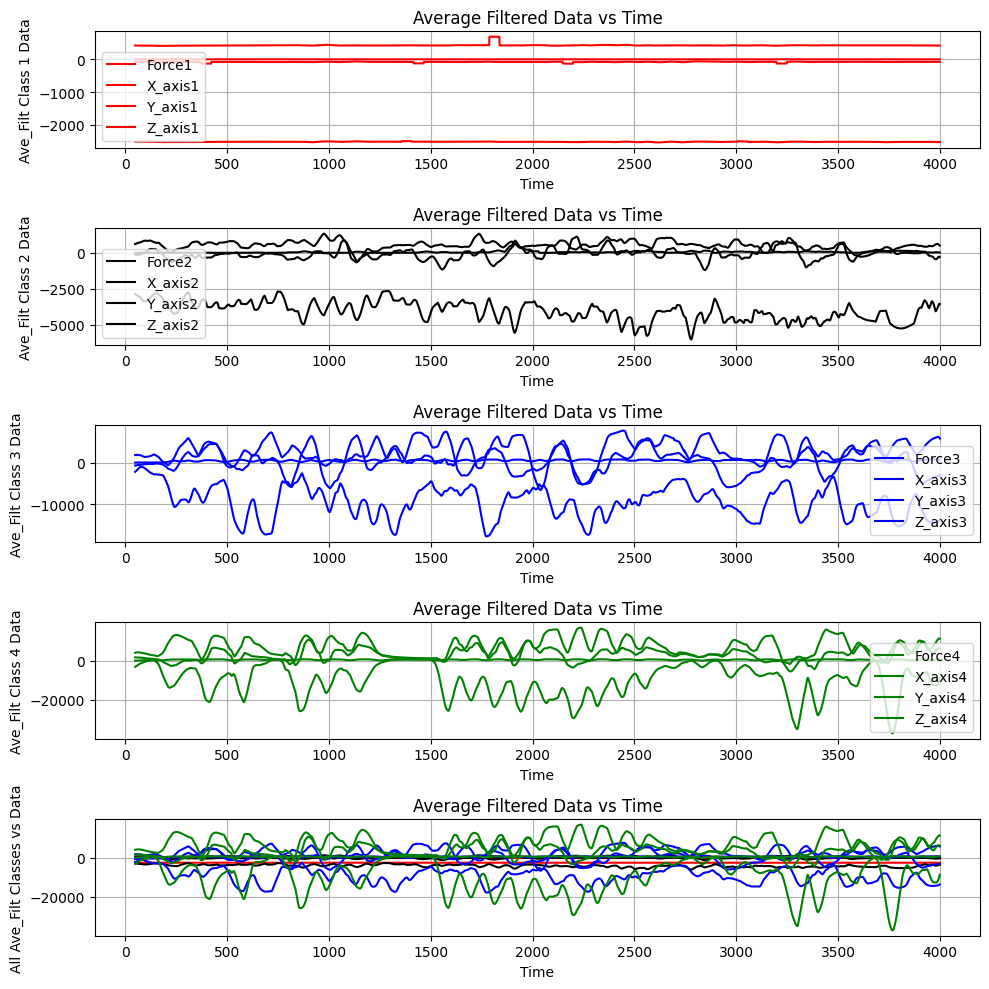

In [7]:
plt.figure("AverageFilteredDataAnalysis", figsize=(10, 10))


plt.subplot(5, 1, 1)
plt.plot(Time[window_size-1:], classOne_ave_filt_force, label='Force1', color='r')
plt.plot(Time[window_size-1:], classOne_ave_filt_xaxis, label='X_axis1', color='r')
plt.plot(Time[window_size-1:], classOne_ave_filt_yaxis, label='Y_axis1', color='r')
plt.plot(Time[window_size-1:], classOne_ave_filt_zaxis , label='Z_axis1', color='r')
plt.xlabel('Time')
plt.ylabel('Ave_Filt Class 1 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 2)
plt.plot(Time[window_size-1:], classTwo_ave_filt_force, label='Force2', color='k')
plt.plot(Time[window_size-1:], classTwo_ave_filt_xaxis, label='X_axis2', color='k')
plt.plot(Time[window_size-1:], classTwo_ave_filt_yaxis, label='Y_axis2', color='k')
plt.plot(Time[window_size-1:], classTwo_ave_filt_zaxis, label='Z_axis2', color='k')
plt.xlabel('Time')
plt.ylabel('Ave_Filt Class 2 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 3)
plt.plot(Time[window_size-1:], classThree_ave_filt_force, label='Force3', color='b')
plt.plot(Time[window_size-1:], classThree_ave_filt_xaxis, label='X_axis3', color='b')
plt.plot(Time[window_size-1:], classThree_ave_filt_yaxis, label='Y_axis3', color='b')
plt.plot(Time[window_size-1:], classThree_ave_filt_zaxis, label='Z_axis3', color='b')
plt.xlabel('Time')
plt.ylabel('Ave_Filt Class 3 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 4)
plt.plot(Time[window_size-1:], classFour_ave_filt_force, label='Force4', color='g')
plt.plot(Time[window_size-1:], classFour_ave_filt_xaxis, label='X_axis4', color='g')
plt.plot(Time[window_size-1:], classFour_ave_filt_yaxis, label='Y_axis4', color='g')
plt.plot(Time[window_size-1:], classFour_ave_filt_zaxis, label='Z_axis4', color='g')
plt.xlabel('Time')
plt.ylabel('Ave_Filt Class 4 Data')
plt.title('Average Filtered Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 5)
plt.plot(Time[window_size-1:], classOne_ave_filt_force, label='Force1', color='r')
plt.plot(Time[window_size-1:], classOne_ave_filt_xaxis, label='X_axis1', color='r')
plt.plot(Time[window_size-1:], classOne_ave_filt_yaxis, label='Y_axis1', color='r')
plt.plot(Time[window_size-1:], classOne_ave_filt_zaxis , label='Z_axis1', color='r')

plt.plot(Time[window_size-1:], classTwo_ave_filt_force, label='Force2', color='k')
plt.plot(Time[window_size-1:], classTwo_ave_filt_xaxis, label='X_axis2', color='k')
plt.plot(Time[window_size-1:], classTwo_ave_filt_yaxis, label='Y_axis2', color='k')
plt.plot(Time[window_size-1:], classTwo_ave_filt_zaxis, label='Z_axis2', color='k')

plt.plot(Time[window_size-1:], classThree_ave_filt_force, label='Force3', color='b')
plt.plot(Time[window_size-1:], classThree_ave_filt_xaxis, label='X_axis3', color='b')
plt.plot(Time[window_size-1:], classThree_ave_filt_yaxis, label='Y_axis3', color='b')
plt.plot(Time[window_size-1:], classThree_ave_filt_zaxis, label='Z_axis3', color='b')

plt.plot(Time[window_size-1:], classFour_ave_filt_force, label='Force4', color='g')
plt.plot(Time[window_size-1:], classFour_ave_filt_xaxis, label='X_axis4', color='g')
plt.plot(Time[window_size-1:], classFour_ave_filt_yaxis, label='Y_axis4', color='g')
plt.plot(Time[window_size-1:], classFour_ave_filt_zaxis, label='Z_axis4', color='g')
plt.xlabel('Time')
plt.ylabel('All Ave_Filt Classes vs Data')
plt.title('Average Filtered Data vs Time')
plt.grid(True)

plt.tight_layout()
plt.show()




In [8]:
# The moving median filter
def median_filter(data, window_size):
    return np.array([np.median(data[i:i+window_size]) for i in range(len(data)-window_size+1)])


classOne_med_filt_force = median_filter(classOne['Force'], window_size)
classOne_med_filt_xaxis = median_filter(classOne['X_axis'], window_size)
classOne_med_filt_yaxis = median_filter(classOne['Y_axis'], window_size)
classOne_med_filt_zaxis = median_filter(classOne['Z_axis'], window_size)

print(classOne_med_filt_force)
print(classOne_med_filt_xaxis)
print(classOne_med_filt_yaxis)
print(classOne_med_filt_zaxis)

print(len(classOne_med_filt_force))
print(len(classOne_med_filt_xaxis))
print(len(classOne_med_filt_yaxis))
print(len(classOne_med_filt_zaxis))

classTwo_med_filt_force = median_filter(classTwo['Force'], window_size)
classTwo_med_filt_xaxis = median_filter(classTwo['X_axis'], window_size)
classTwo_med_filt_yaxis = median_filter(classTwo['Y_axis'], window_size)
classTwo_med_filt_zaxis = median_filter(classTwo['Z_axis'], window_size)

classThree_med_filt_force = median_filter(classThree['Force'], window_size)
classThree_med_filt_xaxis = median_filter(classThree['X_axis'], window_size)
classThree_med_filt_yaxis = median_filter(classThree['Y_axis'], window_size)
classThree_med_filt_zaxis = median_filter(classThree['Z_axis'], window_size)


classFour_med_filt_force = median_filter(classFour['Force'], window_size)
classFour_med_filt_xaxis = median_filter(classFour['X_axis'], window_size)
classFour_med_filt_yaxis = median_filter(classFour['Y_axis'], window_size)
classFour_med_filt_zaxis = median_filter(classFour['Z_axis'], window_size)
print(classFour_med_filt_force)
print(classFour_med_filt_xaxis)
print(classFour_med_filt_yaxis)
print(classFour_med_filt_zaxis)






[0. 0. 0. ... 0. 0. 0.]
[-72.   -72.   -72.   ... -76.5  -76.5  -77.25]
[420.  420.  420.  ... 415.5 415.5 415.5]
[-2506.5 -2506.5 -2506.5 ... -2521.5 -2521.5 -2521.5]
3951
3951
3951
3951
[ 39.   41.5  46.  ... 753.  753.  753.5]
[1734.75 1732.5  1730.25 ... 6393.75 6318.   6318.  ]
[ 4311.75  4333.5   4368.75 ... 10559.25 10559.25 10514.25]
[-2611.5  -2280.   -2139.75 ... -6287.25 -5970.   -5638.5 ]


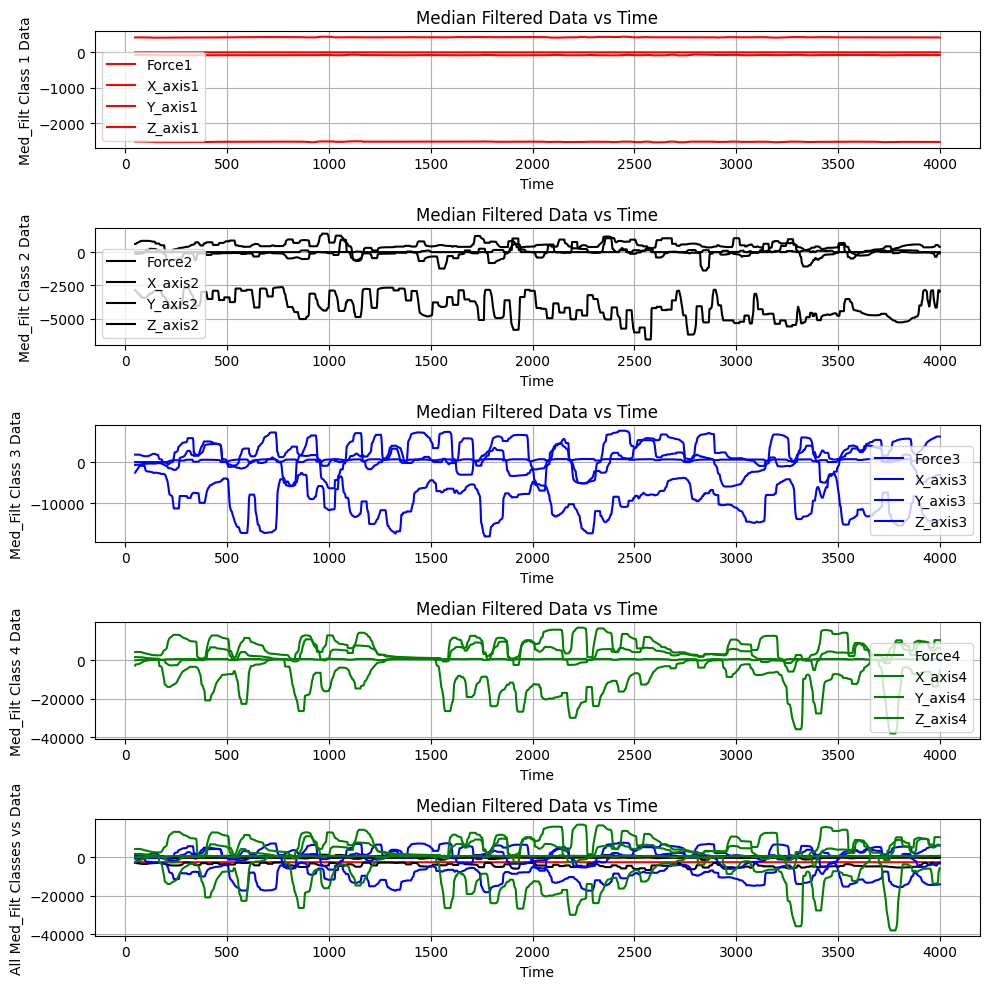

In [32]:
plt.figure("MedianFilteredDataAnalysis", figsize=(10, 10))

plt.subplot(5, 1, 1)
plt.plot(Time[window_size-1:], classOne_med_filt_force, label='Force1', color='r')
plt.plot(Time[window_size-1:], classOne_med_filt_xaxis, label='X_axis1', color='r')
plt.plot(Time[window_size-1:], classOne_med_filt_yaxis, label='Y_axis1', color='r')
plt.plot(Time[window_size-1:], classOne_med_filt_zaxis , label='Z_axis1', color='r')
plt.xlabel('Time')
plt.ylabel('Med_Filt Class 1 Data')
plt.title('Median Filtered Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 2)
plt.plot(Time[window_size-1:], classTwo_med_filt_force, label='Force2', color='k')
plt.plot(Time[window_size-1:], classTwo_med_filt_xaxis, label='X_axis2', color='k')
plt.plot(Time[window_size-1:], classTwo_med_filt_yaxis, label='Y_axis2', color='k')
plt.plot(Time[window_size-1:], classTwo_med_filt_zaxis, label='Z_axis2', color='k')
plt.xlabel('Time')
plt.ylabel('Med_Filt Class 2 Data')
plt.title('Median Filtered Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 3)
plt.plot(Time[window_size-1:], classThree_med_filt_force, label='Force3', color='b')
plt.plot(Time[window_size-1:], classThree_med_filt_xaxis, label='X_axis3', color='b')
plt.plot(Time[window_size-1:], classThree_med_filt_yaxis, label='Y_axis3', color='b')
plt.plot(Time[window_size-1:], classThree_med_filt_zaxis, label='Z_axis3', color='b')
plt.xlabel('Time')
plt.ylabel('Med_Filt Class 3 Data')
plt.title('Median Filtered Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 4)
plt.plot(Time[window_size-1:], classFour_med_filt_force, label='Force4', color='g')
plt.plot(Time[window_size-1:], classFour_med_filt_xaxis, label='X_axis4', color='g')
plt.plot(Time[window_size-1:], classFour_med_filt_yaxis, label='Y_axis4', color='g')
plt.plot(Time[window_size-1:], classFour_med_filt_zaxis, label='Z_axis4', color='g')
plt.xlabel('Time')
plt.ylabel('Med_Filt Class 4 Data')
plt.title('Median Filtered Data vs Time')
plt.legend()
plt.grid(True)

plt.subplot(5, 1, 5)
plt.plot(Time[window_size-1:], classOne_med_filt_force, label='Force1', color='r')
plt.plot(Time[window_size-1:], classOne_med_filt_xaxis, label='X_axis1', color='r')
plt.plot(Time[window_size-1:], classOne_med_filt_yaxis, label='Y_axis1', color='r')
plt.plot(Time[window_size-1:], classOne_med_filt_zaxis , label='Z_axis1', color='r')

plt.plot(Time[window_size-1:], classTwo_med_filt_force, label='Force2', color='k')
plt.plot(Time[window_size-1:], classTwo_med_filt_xaxis, label='X_axis2', color='k')
plt.plot(Time[window_size-1:], classTwo_med_filt_yaxis, label='Y_axis2', color='k')
plt.plot(Time[window_size-1:], classTwo_med_filt_zaxis, label='Z_axis2', color='k')

plt.plot(Time[window_size-1:], classThree_med_filt_force, label='Force3', color='b')
plt.plot(Time[window_size-1:], classThree_med_filt_xaxis, label='X_axis3', color='b')
plt.plot(Time[window_size-1:], classThree_med_filt_yaxis, label='Y_axis3', color='b')
plt.plot(Time[window_size-1:], classThree_med_filt_zaxis, label='Z_axis3', color='b')

plt.plot(Time[window_size-1:], classFour_med_filt_force, label='Force4', color='g')
plt.plot(Time[window_size-1:], classFour_med_filt_xaxis, label='X_axis4', color='g')
plt.plot(Time[window_size-1:], classFour_med_filt_yaxis, label='Y_axis4', color='g')
plt.plot(Time[window_size-1:], classFour_med_filt_zaxis, label='Z_axis4', color='g')
plt.xlabel('Time')
plt.ylabel('All Med_Filt Classes vs Data')
plt.title('Median Filtered Data vs Time')
plt.grid(True)

plt.tight_layout()
plt.show()




In [10]:
combined_ave_filt_force = np.concatenate((classOne_ave_filt_force,classTwo_ave_filt_force,
                                          classThree_ave_filt_force,classFour_ave_filt_force))
print(combined_ave_filt_force)


combined_ave_filt_xaxis = np.concatenate((classOne_ave_filt_xaxis,classTwo_ave_filt_xaxis,
                                          classThree_ave_filt_xaxis,classFour_ave_filt_xaxis))
print(combined_ave_filt_xaxis)


combined_ave_filt_yaxis = np.concatenate((classOne_ave_filt_yaxis,classTwo_ave_filt_yaxis,
                                          classThree_ave_filt_yaxis,classFour_ave_filt_yaxis))
print(combined_ave_filt_yaxis)


combined_ave_filt_zaxis = np.concatenate((classOne_ave_filt_zaxis,classTwo_ave_filt_zaxis,
                                          classThree_ave_filt_zaxis,classFour_ave_filt_zaxis))
print(combined_ave_filt_zaxis)

[-6.0000e-02 -6.0000e-02 -6.0000e-02 ...  7.4280e+02  7.4466e+02
  7.4630e+02]
[ -72.51  -72.36  -72.3  ... 6301.05 6286.95 6280.68]
[  419.79   419.76   419.82 ... 11437.56 11408.82 11358.42]
[-2507.16 -2507.16 -2507.16 ... -9427.08 -9055.44 -8685.42]


In [11]:
combined_med_filt_force = np.concatenate((classOne_med_filt_force,classTwo_med_filt_force,
                                          classThree_med_filt_force,classFour_med_filt_force))
print(combined_med_filt_force)
print(len(combined_med_filt_force))



combined_med_filt_xaxis = np.concatenate((classOne_med_filt_xaxis,classTwo_med_filt_xaxis,
                                          classThree_med_filt_xaxis,classFour_med_filt_xaxis))
print(combined_med_filt_xaxis)


combined_med_filt_yaxis = np.concatenate((classOne_med_filt_yaxis,classTwo_med_filt_yaxis,
                                          classThree_med_filt_yaxis,classFour_med_filt_yaxis))
print(combined_med_filt_yaxis)


combined_med_filt_zaxis = np.concatenate((classOne_med_filt_zaxis,classTwo_med_filt_zaxis,
                                          classThree_med_filt_zaxis,classFour_med_filt_zaxis))
print(combined_med_filt_zaxis)

[  0.    0.    0.  ... 753.  753.  753.5]
15804
[ -72.    -72.    -72.   ... 6393.75 6318.   6318.  ]
[  420.     420.     420.   ... 10559.25 10559.25 10514.25]
[-2506.5  -2506.5  -2506.5  ... -6287.25 -5970.   -5638.5 ]


In [12]:
new_sensorData = pd.DataFrame({
    'ave_filt_force': combined_ave_filt_force,
    'ave_filt_xaxis': combined_ave_filt_xaxis,
    'ave_filt_yaxis': combined_ave_filt_yaxis,
    'ave_filt_zaxis': combined_ave_filt_zaxis,

    'med_filt_force': combined_med_filt_force,
    'med_filt_xaxis': combined_med_filt_xaxis,
    'med_filt_yaxis': combined_med_filt_yaxis,
    'med_filt_zaxis': combined_med_filt_zaxis,

})

split = len(classOne_ave_filt_force)
print(split)

new_sensorData['Class'] = 0
new_sensorData.loc[0:(1*split)-1, 'Class'] = 1
new_sensorData.loc[(1*split):(2*split)-1, 'Class'] = 2
new_sensorData.loc[(2*split):(3*split)-1, 'Class'] = 3
new_sensorData.loc[(3*split):(4*split)-1, 'Class'] = 4

print(new_sensorData)
# print(new_sensorData.head())
new_sensorData.to_csv('combined_sensorData.csv', index=False)



3951
       ave_filt_force  ave_filt_xaxis  ave_filt_yaxis  ave_filt_zaxis  \
0               -0.06          -72.51          419.79        -2507.16   
1               -0.06          -72.36          419.76        -2507.16   
2               -0.06          -72.30          419.82        -2507.16   
3               -0.08          -72.27          419.79        -2507.16   
4               -0.10          -72.21          419.82        -2507.13   
...               ...             ...             ...             ...   
15799          738.50         6342.39        11404.56       -10161.45   
15800          740.78         6319.83        11440.38        -9798.66   
15801          742.80         6301.05        11437.56        -9427.08   
15802          744.66         6286.95        11408.82        -9055.44   
15803          746.30         6280.68        11358.42        -8685.42   

       med_filt_force  med_filt_xaxis  med_filt_yaxis  med_filt_zaxis  Class  
0                 0.0          -72.00  

In [13]:


# series = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\sktime-tutorial-pydata-global-2021\\notebooks\\multivariatetest_data.csv', header=0, parse_dates=[0], index_col=0, squeeze=True)
# series = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\Arduino_train_test_labels.csv', header=0, parse_dates=[0], index_col=0, squeeze=True)
# series = pd.read_csv('C:\\Users\\dema2\\OneDrive\\Desktop\\PhD\\RFMN\\Reflex-Fuzzy-Network\\Arduino_train_test_labelsDWL.csv', header=0, parse_dates=[0], index_col=0, squeeze=True)
# series = pd.read_csv('features_train_test_copy.csv', header=0, parse_dates=[0], index_col=0, squeeze=True)
# series = pd.read_csv('features_train_test_copy.csv')

series = pd.read_csv('combined_sensorData.csv')

print(type(series))
print(series.head(8000))

<class 'pandas.core.frame.DataFrame'>
      ave_filt_force  ave_filt_xaxis  ave_filt_yaxis  ave_filt_zaxis  \
0              -0.06          -72.51          419.79        -2507.16   
1              -0.06          -72.36          419.76        -2507.16   
2              -0.06          -72.30          419.82        -2507.16   
3              -0.08          -72.27          419.79        -2507.16   
4              -0.10          -72.21          419.82        -2507.13   
...              ...             ...             ...             ...   
7995           -0.28         -301.47         1917.27        -2835.99   
7996           -0.30         -295.74         1905.60        -2828.10   
7997           -0.30         -289.44         1891.53        -2819.55   
7998           -0.30         -282.96         1874.94        -2810.58   
7999           -0.28         -276.06         1851.99        -2804.04   

      med_filt_force  med_filt_xaxis  med_filt_yaxis  med_filt_zaxis  Class  
0                0.

In [14]:
columns_to_combine = series.columns[:-1]
print(columns_to_combine)
print(columns_to_combine.size)

combined_array = []


# Loop through each column, extract values, and append to combined_array
for column in columns_to_combine:
    new_array = series[column].to_numpy()
    print(new_array.size)
    combined_array.append(new_array)

combined_array = np.column_stack(combined_array)

y = series.iloc[:,-1].to_numpy() 
print(y)

label_map = {1: 0, 2: 1, 3: 2, 4: 3}
y = np.array([label_map[label] for label in y])
print(y)



Index(['ave_filt_force', 'ave_filt_xaxis', 'ave_filt_yaxis', 'ave_filt_zaxis',
       'med_filt_force', 'med_filt_xaxis', 'med_filt_yaxis', 'med_filt_zaxis'],
      dtype='object')
8
15804
15804
15804
15804
15804
15804
15804
15804
[1 1 1 ... 4 4 4]
[0 0 0 ... 3 3 3]


In [15]:
# np.set_printoptions(threshold=np.inf)
print(combined_array)
print(type(combined_array))
print(combined_array.shape)




y = y[~np.isnan(y)]
print(y.shape)
print(y)
print(y.size)





[[-6.000000e-02 -7.251000e+01  4.197900e+02 ... -7.200000e+01
   4.200000e+02 -2.506500e+03]
 [-6.000000e-02 -7.236000e+01  4.197600e+02 ... -7.200000e+01
   4.200000e+02 -2.506500e+03]
 [-6.000000e-02 -7.230000e+01  4.198200e+02 ... -7.200000e+01
   4.200000e+02 -2.506500e+03]
 ...
 [ 7.428000e+02  6.301050e+03  1.143756e+04 ...  6.393750e+03
   1.055925e+04 -6.287250e+03]
 [ 7.446600e+02  6.286950e+03  1.140882e+04 ...  6.318000e+03
   1.055925e+04 -5.970000e+03]
 [ 7.463000e+02  6.280680e+03  1.135842e+04 ...  6.318000e+03
   1.051425e+04 -5.638500e+03]]
<class 'numpy.ndarray'>
(15804, 8)
(15804,)
[0 0 0 ... 3 3 3]
15804


In [16]:
X = combined_array.reshape(y.size,columns_to_combine.size,1)
# X = combined_array.reshape(720,6,5)

# X = combined_array.reshape(int(y.size/11),columns_to_combine.size,11) #Should be less than or requal to 
                                                                        # colums_to_combine.size
# X = combined_array.reshape(y.size,columns_to_combine.size,1)


print(X)
# np.unique(y)
# y = y.astype('<U1')
np.unique(y)
print(y)
print(X.shape)
print(y.shape)

[[[-6.000000e-02]
  [-7.251000e+01]
  [ 4.197900e+02]
  ...
  [-7.200000e+01]
  [ 4.200000e+02]
  [-2.506500e+03]]

 [[-6.000000e-02]
  [-7.236000e+01]
  [ 4.197600e+02]
  ...
  [-7.200000e+01]
  [ 4.200000e+02]
  [-2.506500e+03]]

 [[-6.000000e-02]
  [-7.230000e+01]
  [ 4.198200e+02]
  ...
  [-7.200000e+01]
  [ 4.200000e+02]
  [-2.506500e+03]]

 ...

 [[ 7.428000e+02]
  [ 6.301050e+03]
  [ 1.143756e+04]
  ...
  [ 6.393750e+03]
  [ 1.055925e+04]
  [-6.287250e+03]]

 [[ 7.446600e+02]
  [ 6.286950e+03]
  [ 1.140882e+04]
  ...
  [ 6.318000e+03]
  [ 1.055925e+04]
  [-5.970000e+03]]

 [[ 7.463000e+02]
  [ 6.280680e+03]
  [ 1.135842e+04]
  ...
  [ 6.318000e+03]
  [ 1.051425e+04]
  [-5.638500e+03]]]
[0 0 0 ... 3 3 3]
(15804, 8, 1)
(15804,)


In [17]:
def normalize_standard(X, scaler=None):
    shape = X.shape
    data_flat = X.flatten()
    if scaler is None:
        scaler = StandardScaler()
        data_transformed = scaler.fit_transform(data_flat.reshape(np.product(shape), 1)).reshape(shape)
    else:
        data_transformed = scaler.transform(data_flat.reshape(np.product(shape), 1)).reshape(shape)
    return data_transformed, scaler

def normalize_data(X, scaler=None):
    if scaler is None:
        X, scaler = normalize_standard(X)
    else:
        X, scaler = normalize_standard(X, scaler)
    
    return X, scaler





X, scaler = normalize_data(X)
print(f"X {X}")

print(f"Shape X: {X.shape}")
# print(f"Shape y_train: {y_train.shape}")

X [[[ 0.13457533]
  [ 0.1204134 ]
  [ 0.21664414]
  ...
  [ 0.12051309]
  [ 0.21668519]
  [-0.35536286]]

 [[ 0.13457533]
  [ 0.12044272]
  [ 0.21663827]
  ...
  [ 0.12051309]
  [ 0.21668519]
  [-0.35536286]]

 [[ 0.13457533]
  [ 0.12045445]
  [ 0.21665   ]
  ...
  [ 0.12051309]
  [ 0.21668519]
  [-0.35536286]]

 ...

 [[ 0.27978346]
  [ 1.36626426]
  [ 2.37030681]
  ...
  [ 1.38438449]
  [ 2.19862202]
  [-1.09439264]]

 [[ 0.28014704]
  [ 1.36350811]
  [ 2.36468895]
  ...
  [ 1.36957751]
  [ 2.19862202]
  [-1.03237923]]

 [[ 0.28046762]
  [ 1.3622825 ]
  [ 2.35483717]
  ...
  [ 1.36957751]
  [ 2.18982579]
  [-0.96758035]]]
Shape X: (15804, 8, 1)


In [18]:
X_train, X_test, y_train, y_test = train_test_split(X, y, test_size=0.33)

print(X_train)
print(X_test)
print(y_train)
print(y_test)

[[[ 0.18710249]
  [-0.34778051]
  [ 0.56844049]
  ...
  [-0.23236227]
  [ 0.50402864]
  [-1.46779253]]

 [[ 0.20473014]
  [ 0.13792962]
  [ 0.06137312]
  ...
  [ 0.11376932]
  [ 0.16244178]
  [-1.86714129]]

 [[ 0.1345206 ]
  [ 0.11878317]
  [ 0.21646235]
  ...
  [ 0.11875385]
  [ 0.21639198]
  [-0.3568289 ]]

 ...

 [[ 0.25549806]
  [ 1.52608586]
  [ 1.02907551]
  ...
  [ 1.49228489]
  [ 1.03957234]
  [-0.48701307]]

 [[ 0.14098289]
  [ 0.0063791 ]
  [ 0.27232426]
  ...
  [-0.0256509 ]
  [ 0.27210143]
  [-0.41840249]]

 [[ 0.17421309]
  [ 0.01843579]
  [ 0.02578944]
  ...
  [ 0.09690988]
  [ 0.24659236]
  [-1.89235715]]]
[[[ 0.13455187]
  [ 0.11857792]
  [ 0.2168787 ]
  ...
  [ 0.11846064]
  [ 0.2169784 ]
  [-0.3571221 ]]

 [[ 0.23854675]
  [-0.8981781 ]
  [ 0.60817599]
  ...
  [-0.98077469]
  [ 0.65722962]
  [-0.78769748]]

 [[ 0.13452842]
  [ 0.17748919]
  [ 0.225974  ]
  ...
  [ 0.13927838]
  [ 0.21375311]
  [-0.41884231]]

 ...

 [[ 0.25503283]
  [ 1.40499699]
  [ 0.51908779]
  ..

In [19]:
def sample_ts_segments(X, shapelets_size, n_segments=10000):
    """
    Sample time series segments for k-Means.
    """
    n_ts, n_channels, len_ts = X.shape
    samples_i = random.choices(range(n_ts), k=n_segments)
    segments = np.empty((n_segments, n_channels, shapelets_size))
    for i, k in enumerate(samples_i):
        s = random.randint(0, len_ts - shapelets_size)
        segments[i] = X[k, :, s:s+shapelets_size]
    return segments


In [20]:
def get_weights_via_kmeans(X, shapelets_size, num_shapelets, n_segments=10000):
    """
    Get weights via k-Means for a block of shapelets.
    """
    segments = sample_ts_segments(X, shapelets_size, n_segments).transpose(0, 2, 1)
    k_means = TimeSeriesKMeans(n_clusters=num_shapelets, metric="euclidean", max_iter=50).fit(segments)
    clusters = k_means.cluster_centers_.transpose(0, 2, 1)
    return clusters

In [21]:
n_ts, n_channels, len_ts = X_train.shape
loss_func = nn.CrossEntropyLoss()
num_classes = len(set(y_train))
# learn 2 shapelets of length 130
shapelets_size_and_len = {1: 130}
dist_measure = "euclidean"
lr = 1e-2
wd = 1e-3
epsilon = 1e-7

print(X_train.shape)
print(n_ts)
print(n_channels)
print(len_ts)
print(shapelets_size_and_len)

(10588, 8, 1)
10588
8
1
{1: 130}


In [22]:
learning_shapelets = LearningShapelets(shapelets_size_and_len=shapelets_size_and_len,
                                       in_channels=n_channels,
                                       num_classes=num_classes,
                                       loss_func=loss_func,
                                       to_cuda=False,
                                       verbose=1,
                                       dist_measure=dist_measure)

In [23]:
for i, (shapelets_size, num_shapelets) in enumerate(shapelets_size_and_len.items()):
    weights_block = get_weights_via_kmeans(X_train, shapelets_size, num_shapelets)
    learning_shapelets.set_shapelet_weights_of_block(i, weights_block)

In [24]:
optimizer = optim.Adam(learning_shapelets.model.parameters(), lr=lr, weight_decay=wd, eps=epsilon)
learning_shapelets.set_optimizer(optimizer)

In [25]:
losses = learning_shapelets.fit(X_train, y_train, epochs=2000, batch_size=256, shuffle=False, drop_last=False)

Loss: 0.10219814628362656: 100%|██████████| 2000/2000 [14:26<00:00,  2.31it/s]


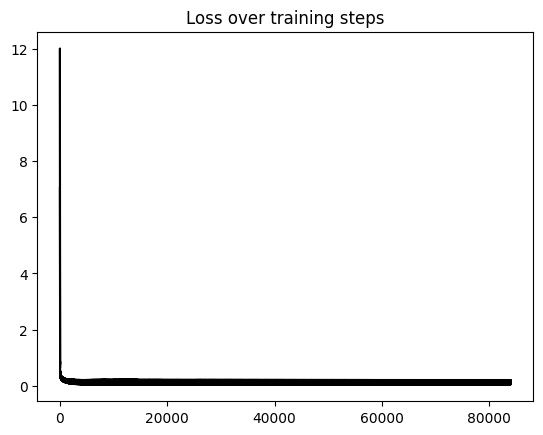

In [26]:
plt.plot(losses, color='black')
plt.title("Loss over training steps")
plt.show()

In [27]:


def eval_accuracy(model, X, Y):
    result = []
    predictions = model.predict(X)
    if len(predictions.shape) == 2:
        predictions = predictions.argmax(axis=1)
        print(predictions)
    print(type(predictions))
    print(predictions.shape)

    result.append(predictions)
    print(f"Accuracy: {(predictions == Y).sum() / Y.size}")
    return result




In [28]:
y_predlr = np.array(eval_accuracy(learning_shapelets, X_test, y_test)).reshape(-1)

print(y_predlr)
print(type(y_predlr))
print(y_predlr.shape)

# print(X_test)
# print(y_test)



[0 2 1 ... 2 3 0]
<class 'numpy.ndarray'>
(5216,)
Accuracy: 0.9718174846625767
[0 2 1 ... 2 3 0]
<class 'numpy.ndarray'>
(5216,)


In [29]:
from sklearn.preprocessing import MinMaxScaler
import seaborn as sns
from sklearn.metrics import classification_report, confusion_matrix, accuracy_score, precision_score, recall_score, f1_score, fbeta_score, matthews_corrcoef
from sklearn.utils.multiclass import unique_labels



# check results
print("confusion_matrix \n", confusion_matrix(y_test, y_predlr), "\n")
print("classification_report \n", classification_report(y_test, y_predlr), "\n")


confusion_matrix 
 [[1302    0    0    0]
 [  19 1308    0    0]
 [   0   29 1188   38]
 [   0    0   61 1271]] 

classification_report 
               precision    recall  f1-score   support

           0       0.99      1.00      0.99      1302
           1       0.98      0.99      0.98      1327
           2       0.95      0.95      0.95      1255
           3       0.97      0.95      0.96      1332

    accuracy                           0.97      5216
   macro avg       0.97      0.97      0.97      5216
weighted avg       0.97      0.97      0.97      5216
 



In [30]:
np.set_printoptions(threshold=sys.maxsize)
unique_labels(y_test)

def plot1(y_true, y_pred):
    labels = unique_labels(y_test)
    column = [f'Predicted {label}' for label in labels]
    indices = [f'Actual {label}' for label in labels]
    table = pd.DataFrame(confusion_matrix(y_true, y_pred), columns = column, index=indices)

    return table


plot1(y_test, y_predlr)

,Predicted 0,Predicted 1,Predicted 2,Predicted 3
Actual 0,1302,0,0,0
Actual 1,19,1308,0,0
Actual 2,0,29,1188,38
Actual 3,0,0,61,1271


0.9718174846625767


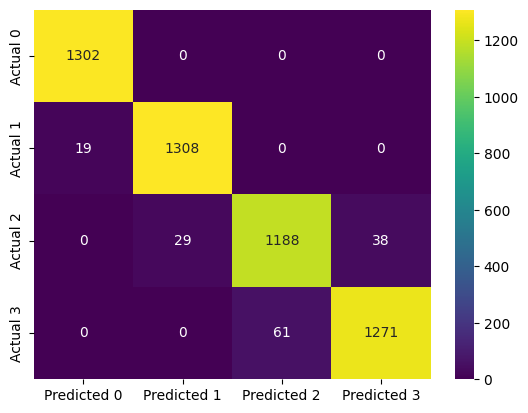

In [31]:
def plot2(y_true, y_pred):
    labels = unique_labels(y_test)
    column = [f'Predicted {label}' for label in labels]
    indices = [f'Actual {label}' for label in labels]
    table = pd.DataFrame(confusion_matrix(y_true, y_pred), columns = column, index=indices)

    return sns.heatmap(table, annot = True, fmt = 'd', cmap= 'viridis')

plot2(y_test, y_predlr)

accuracy_score1 = accuracy_score(y_test, y_predlr)
print(accuracy_score1)